Running Dynamics...


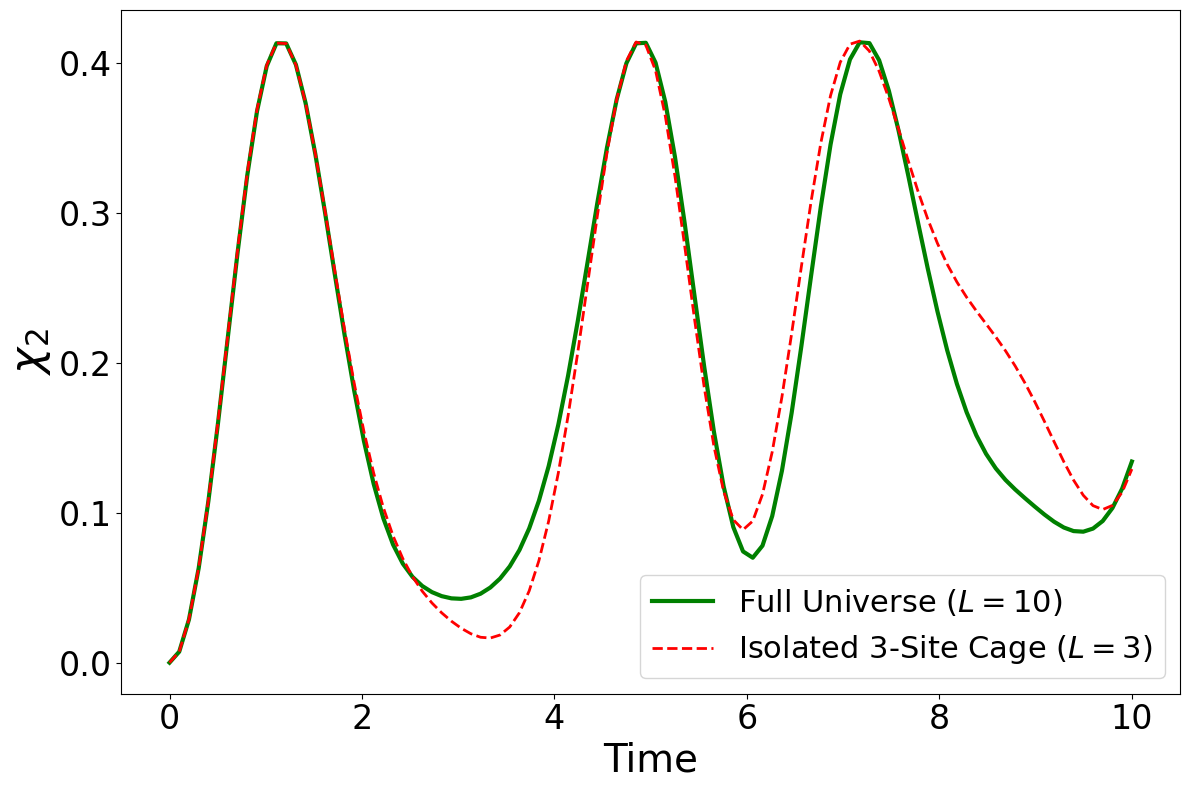

In [2]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import expm_multiply
import matplotlib.pyplot as plt
import os

def get_exact_reduced_rho(psi, L, target_sites):
    psi_tensor = psi.reshape([2] * L)
    axes_to_keep = list(target_sites)
    axes_to_trace =[i for i in range(L) if i not in target_sites]
    psi_tensor = np.moveaxis(psi_tensor, axes_to_keep, range(len(axes_to_keep)))
    dim_keep = 2 ** len(target_sites)
    psi_mat = psi_tensor.reshape(dim_keep, -1)
    return np.dot(psi_mat, psi_mat.conj().T)

def calc_H2_exact(rho):
    purity = np.clip(np.real(np.trace(rho @ rho)), 1e-10, 1.0)
    return np.log2(2.0 / (1.0 + purity))

def build_mbl_hamiltonian(L, fields):
    sx = sp.csr_matrix([[0,1],[1,0]]); sy = sp.csr_matrix([[0,-1j],[1j,0]]); sz = sp.csr_matrix([[1,0],[0,-1]]); id2 = sp.identity(2)
    H = sp.csr_matrix((2**L, 2**L), dtype=complex)
    
    def kron_list(ops):
        res = ops[0]
        for m in ops[1:]: res = sp.kron(res, m)
        return res

    J_pauli = 0.25 
    for i in range(L-1):
        for op in [sx, sy, sz]: 
            ops=[id2]*L; ops[i]=op; ops[i+1]=op; H += J_pauli * kron_list(ops)
    for i in range(L): 
        ops=[id2]*L; ops[i]=sz; H += (fields[i]*0.5) * kron_list(ops)
    return H

L_full = 10
L_cage = 3
W = 8.0
times = np.linspace(0, 10, 100)

# 1. 设定随机场 
np.random.seed(42)
fields_full = np.random.uniform(-W, W, L_full)

# 提取中心 3 个格点的磁场，用于构建牢笼
center_idx = L_full // 2  # 索引为 5
fields_cage = fields_full[center_idx - 1 : center_idx + 2] # 索引 4, 5, 6

# 2. 构建哈密顿量
H_full = build_mbl_hamiltonian(L_full, fields_full)
H_cage = build_mbl_hamiltonian(L_cage, fields_cage)

# 3. 制备初态 (Néel 态)
neel_full = sum([1 << (L_full - 1 - i) for i in range(0, L_full, 2)])
psi_full = np.zeros(2**L_full, dtype=complex); psi_full[neel_full] = 1.0

cage_int = (1 << 2) + (0 << 1) + (1 << 0) 
psi_cage = np.zeros(2**L_cage, dtype=complex); psi_cage[cage_int] = 1.0

# 4. 演化并记录中心格点的 H_2(Q_2) 熵
h2_full_list = []
h2_cage_list =[]

print("Running Dynamics...")
traj_full = expm_multiply(-1j * H_full, psi_full, start=times[0], stop=times[-1], num=len(times))
traj_cage = expm_multiply(-1j * H_cage, psi_cage, start=times[0], stop=times[-1], num=len(times))

for t in range(len(times)):
    rho_full = get_exact_reduced_rho(traj_full[t], L_full, [center_idx])
    h2_full_list.append(calc_H2_exact(rho_full))
    
    rho_cage = get_exact_reduced_rho(traj_cage[t], L_cage,[1])
    h2_cage_list.append(calc_H2_exact(rho_cage))

save_dir = r"E:\Quantum_Scar_Project\classical mutual information\数据集"
os.makedirs(save_dir, exist_ok=True)
np.savez(
    os.path.join(save_dir, "MBL_analysis.npz"),
    times=times,                
    h2_full=np.array(h2_full_list),  
    h2_cage=np.array(h2_cage_list),  
    L_full=L_full,              
    L_cage=L_cage,
    W=W
)

# 5. 绘图
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(times, h2_full_list, 'g-', lw=3, label=f"Full Universe ($L={L_full}$)")
ax.plot(times, h2_cage_list, 'r--', lw=2, label=f"Isolated 3-Site Cage ($L={L_cage}$)")
ax.set_xlabel("Time", fontsize=28)
ax.set_ylabel(r"$\chi_2$", fontsize=32)
ax.tick_params(axis='both', labelsize=24)
ax.grid(False)
ax.legend(fontsize=22)
plt.tight_layout()
fig.savefig("MBL：拎中间三格点为另一系统.png", dpi=300, bbox_inches="tight")
plt.show()